# Choosing the right estimator/algorithm

In supervised learning there are several types of model such as:

1. Regression - Predicts a number
2. Classification - Predicts a type of output

Scikit learn has provided a nice cheat sheet to provide a guideline for choosing an estimator.

![sklearn-alogorithm cheat-sheat](https://scikit-learn.org/stable/_static/ml_map.png)

So, let's start with a regression problem

## Regression Problem

In [1]:
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np

In [2]:
load_diabetes().keys()

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

Let's read the description

In [3]:
print(load_diabetes().DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

  :Number of Instances: 442

  :Number of Attributes: First 10 columns are numeric predictive values

  :Target: Column 11 is a quantitative measure of disease progression one year after baseline

  :Attribute Information:
      - age     age in years
      - sex
      - bmi     body mass index
      - bp      average blood pressure
      - s1      tc, total serum cholesterol
      - s2      ldl, low-density lipoproteins
      - s3      hdl, high-density lipoproteins
      - s4      tch, total cholesterol / HDL
      - s5      ltg, possibly log of serum triglycerides level
      - s6      glu, blood sugar level

Note: Each of these 1

Let's load the database as X and y

In [23]:
X, y = load_diabetes(as_frame=True, return_X_y=True)

In [24]:
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [25]:
y.head()

0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64

In [26]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


Observation: So, by looking at the data and types we can say that it is a regression problem. Because the target variable is a nubmer and it is labeled.

We can also see the number of sample is 442.

So, let's start following the Sklearn algorithm cheat sheet and choose a model!

By observing the mind map we can start with these models in chronological orders:

    1. RidgeRegression
    2. SVR (linear kernel)
    3. Ensemble Classifiers such as RandomForestRegressors

Before modeling, let's split our data into train-test.

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y)

### 1. RidgeRegression

See the doc [here](https://scikit-learn.org/stable/modules/linear_model.html#ridge-regression)

It has a complexity parameter, &alpha; $\ge$ 0 . 

the larger the value of 
&alpha;, the greater the amount of shrinkage and thus the coefficients become more robust to collinearity.

In [37]:
from sklearn import linear_model, svm
from sklearn.ensemble import RandomForestRegressor

# reg = linear_model.Ridge(alpha=0.2)
reg = linear_model.LassoLars(alpha=0.1)
# reg = RandomForestRegressor(n_estimators=100)

reg.fit(X_train, y_train)

# model evaluation
reg.score(X_test, y_test)

0.5142894955597574

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

Trying with 499.90. Progress: 100.00%...
So a good estimator is: 0.0 with a score of: 0.4789105985787847


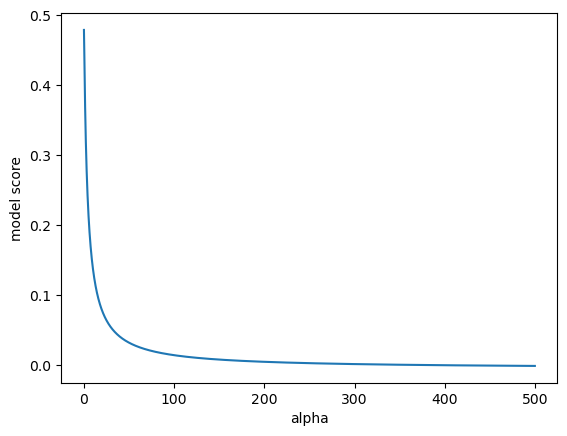

In [39]:
x_ = np.arange(0, 500, step=0.1)
max_x_ = x_.max()


def calc_score(x):
    # reg = linear_model.Ridge(alpha=x)
    progress = 100 - ((max_x_ - x)/max_x_)* 100
    print(f"\rTrying with {x :<0.2f}. Progress: {progress :<0.2f}%...", end="")
    # reg = RandomForestRegressor(n_estimators=x)
    reg = linear_model.Ridge(alpha=x)
    reg.fit(X_train, y_train)
    return reg.score(X_test, y_test)

vfunc = np.vectorize(calc_score)
y_ = vfunc(x_)

import matplotlib.pyplot as plt
plt.plot(x_, y_)
plt.xlabel("alpha")
plt.ylabel("model score")
print("\nSo a good estimator is:", x_[y_.argmax()], "with a score of:", y_.max())

## 2. Classification Model

In [40]:
import pandas as pd
import numpy as np

In [43]:
df = pd.read_csv("data/heart-disease.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


Looking at our  `target` column, we see that it is a categorical data. So, let's treat it as a classification problem

In [42]:
from sklearn.model_selection import train_test_split

target_variable = "target"
X = df.drop(target_variable, axis=1)
y = df[target_variable]

X_train, X_test, y_train, y_test = train_test_split(X, y)

from the sklearn cheat sheet, 
1. Let's do a Linear SVC
2. Then we'll do a Random Forest (ensemble method)

### 1. Linear SVC

In [50]:
from sklearn.svm import LinearSVC

clf = LinearSVC(max_iter=500000)
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

C:\ProgramData\anaconda3\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


0.8421052631578947

### 2. Random Forest

In [62]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()

clf.fit(X_train, y_train)
clf.score(X_test, y_test)

0.8289473684210527